# Realistic Distributions Diagnostics Playground

Tweak parameters, run simulations, and validate the realistic market features.

In [1]:
import sys
sys.path.insert(0, '../src')

from rfq_simulator.config import SimConfig, ArrivalConfig, SpreadConfig, ImbalanceConfig
from rfq_simulator.simulation import run_simulation
from rfq_simulator.output import ValidationReport
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Configure Your Simulation

**Play with these parameters:**

In [2]:
cfg = SimConfig(
    T_days=60,
    seed=42,
    
    # === HAWKES ARRIVALS ===
    # Try: alpha=0.6, beta=0.8 for stronger clustering
    # Try: alpha=0.2, beta=0.8 for weaker clustering
    arrivals=ArrivalConfig(
        use_hawkes=True,
        hawkes_alpha=0.4,  # Excitation strength (higher = more clustering)
        hawkes_beta=0.8,   # Decay rate (higher = faster decay)
    ),
    
    # === LOGNORMAL SPREADS ===
    # Try: mu_stressed=4.0 for even wider stressed spreads
    spreads=SpreadConfig(
        use_lognormal=True,
        mu_calm=2.0,       # log-mean for calm (~7 bps median)
        mu_stressed=3.2,   # log-mean for stressed (~25 bps median)
        sigma_calm=0.5,
        sigma_stressed=0.8,
    ),
    
    # === AR(1) IMBALANCE ===
    # Try: mu_stressed=-0.4 for stronger sell bias
    # Try: rho=0.7 for more persistent flow
    imbalance=ImbalanceConfig(
        use_ar1=True,
        rho=0.4,           # Persistence (higher = longer trends)
        mu_stressed=-0.25, # Sell bias in stress (more negative = more selling)
    ),
)

## 2. Run Simulation & Generate Report

/home/ak/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/ak/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# Realistic Distributions Validation Report
**Summary:** Validated: Hawkes Arrivals, LogNormal Spreads, AR(1) Imbalance. Hawkes ACF(1)=0.087. Spread widening 3.2x. Regime buy diff 13.0%.
---
## ✓ Hawkes Arrivals
✓ RFQ arrivals show significant clustering (ACF(1)=0.087). Branching ratio α/β=0.50 indicates moderate self-excitation.

**Statistics:**
- acf_lag1: 0.0866
- acf_lag5: -0.0218
- ljung_box_stat: nan
- ljung_box_p: nan
- branching_ratio: 0.5000
---
## ✓ LogNormal Spreads
✓ Spreads are log-normally distributed (Shapiro p=0.758). Median: 7.4 bps (calm) → 23.7 bps (stressed), a 3.2x widening during stress.

**Statistics:**
- calm_median: 7.4119
- stressed_median: 23.6881
- regime_ratio: 3.1959
- shapiro_stat: 0.9988
- shapiro_p: 0.7576
- cfg_mu_calm: 2.0000
- cfg_mu_stressed: 3.2000
- trader_calm_median: 8.2000
- trader_stressed_median: 8.2000
- n_calm_fills: 646
- n_stressed_fills: 368
---
## ✓ AR(1) Imbalance
✓ Flow shows persistence (ACF(1)=0.122, expected rho=0.40). Stressed: 36.3% buys vs calm: 49.3% (-13.0% difference).
**Warnings:**
- ACF(1)=0.122 differs from rho=0.40

**Statistics:**
- buy_frac_calm: 0.4935
- buy_frac_stressed: 0.3633
- buy_frac_diff: 0.1302
- direction_acf1: 0.1225
- direction_acf5: 0.0381
- cfg_rho: 0.4000
- cfg_mu_stressed: -0.2500
---


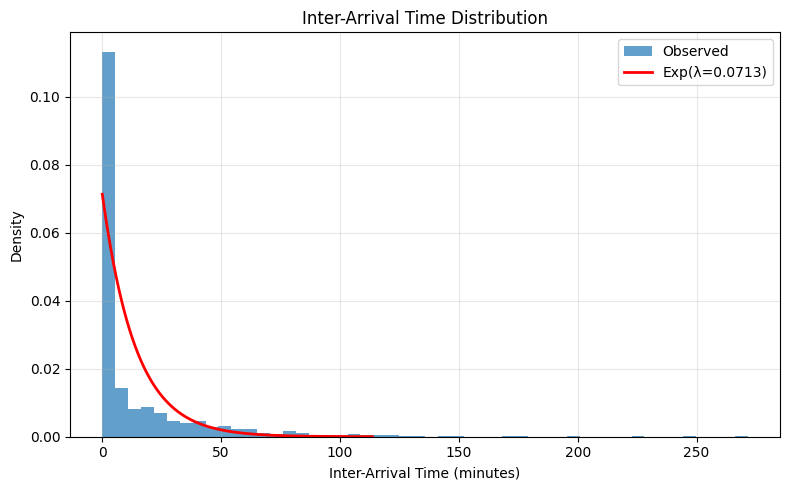

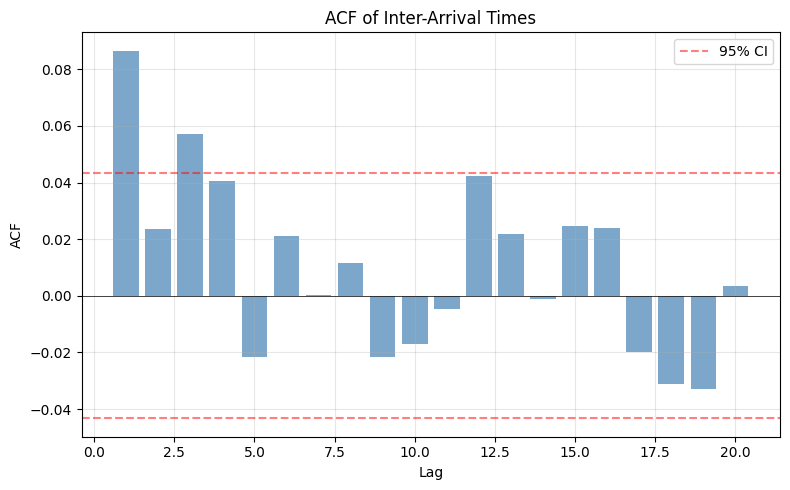

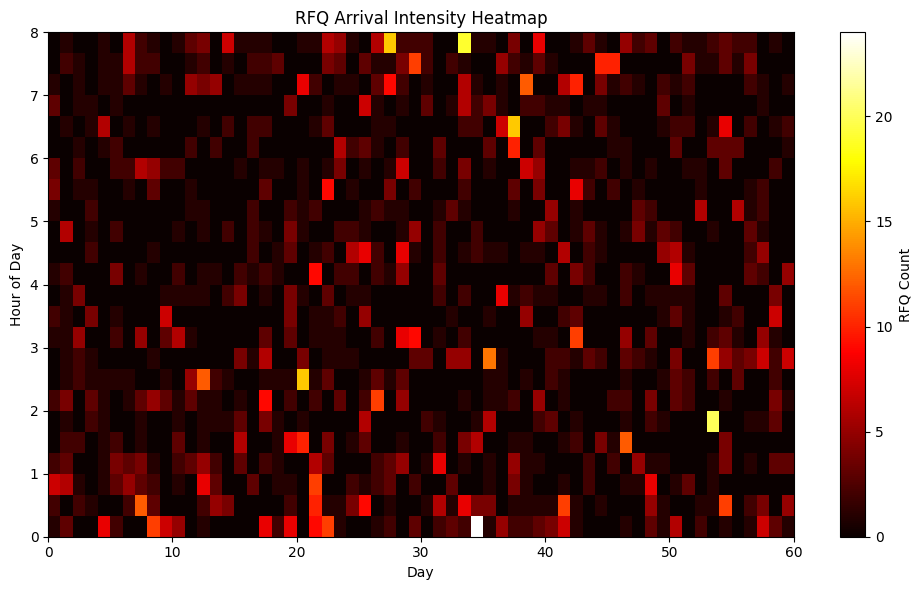

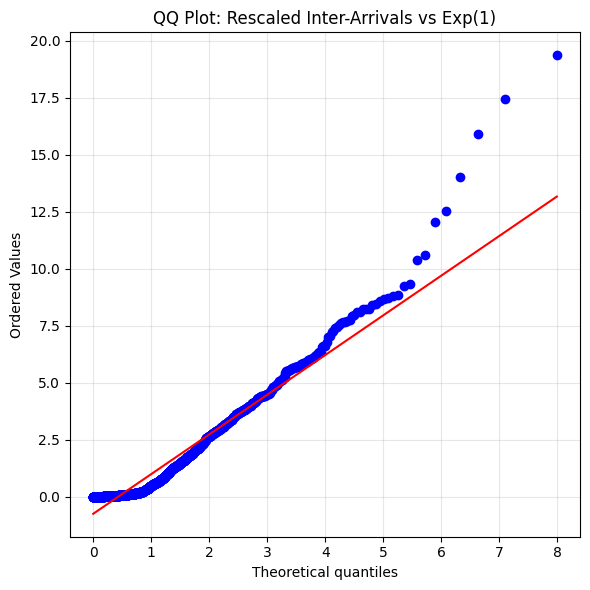

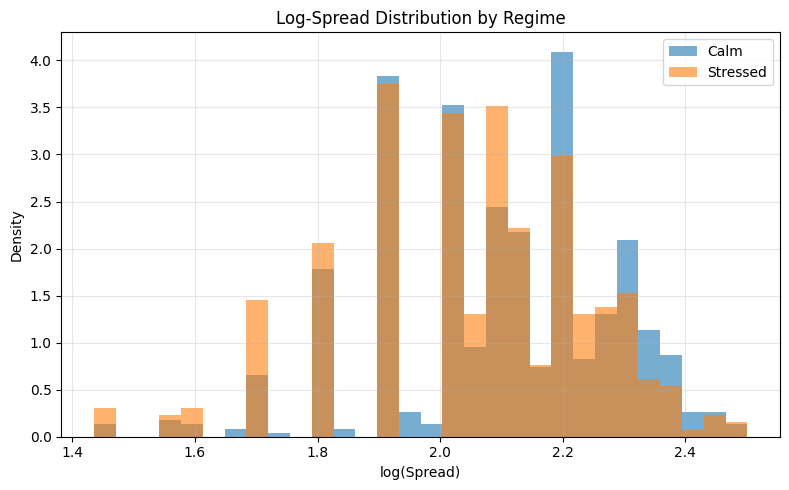

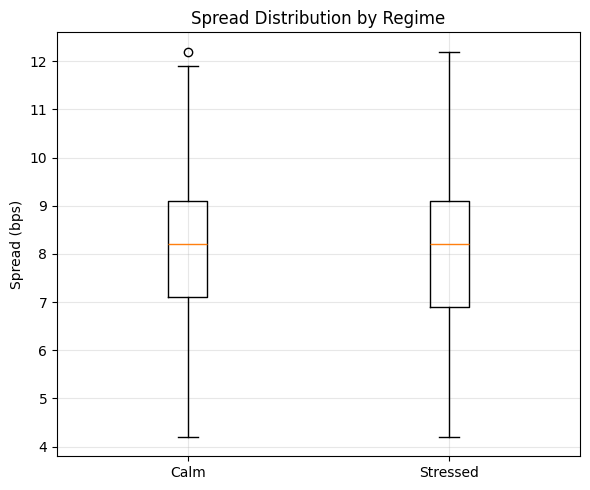

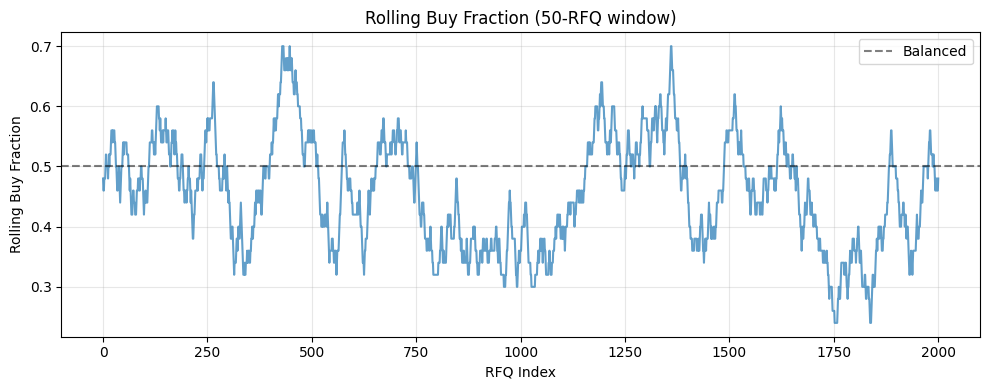

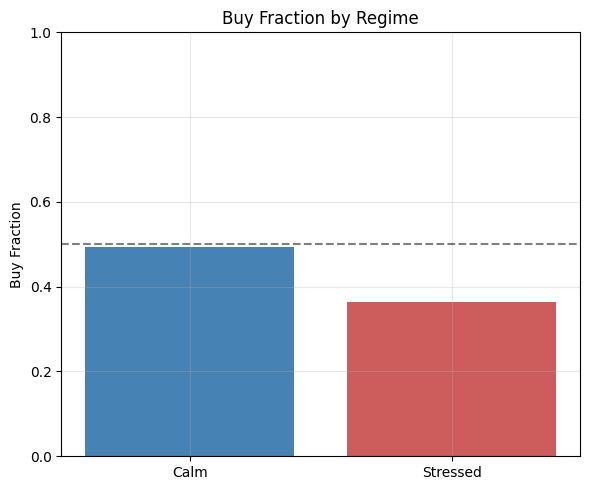

In [3]:
result = run_simulation(cfg)
report = ValidationReport(result)
report.display()

## 3. Drill Into Individual Diagnostics

Hawkes passed: True
ACF(1): 0.0866
Branching ratio: 0.50

Narrative: ✓ RFQ arrivals show significant clustering (ACF(1)=0.087). Branching ratio α/β=0.50 indicates moderate self-excitation.


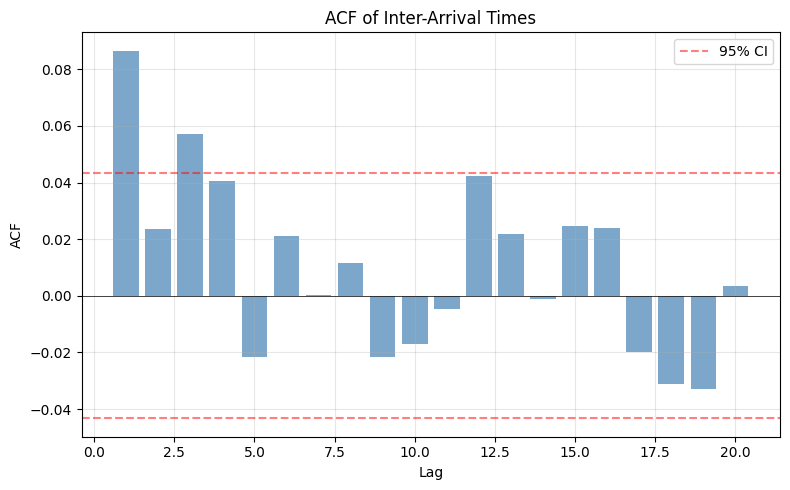

In [4]:
# Access individual diagnostics
hawkes_result = report.hawkes.analyze(generate_plots=True)
print(f"Hawkes passed: {hawkes_result.passed}")
print(f"ACF(1): {hawkes_result.stats['acf_lag1']:.4f}")
print(f"Branching ratio: {hawkes_result.stats['branching_ratio']:.2f}")
print(f"\nNarrative: {hawkes_result.narrative}")

# Show just the ACF plot
hawkes_result.figures[1]  # 0=histogram, 1=ACF, 2=heatmap, 3=QQ

## 4. Compare Different Configurations

In [5]:
# Quick comparison function
def compare_hawkes(alpha_values):
    fig, axes = plt.subplots(1, len(alpha_values), figsize=(5*len(alpha_values), 4))
    
    for ax, alpha in zip(axes, alpha_values):
        cfg = SimConfig(
            T_days=30, seed=42,
            arrivals=ArrivalConfig(use_hawkes=True, hawkes_alpha=alpha, hawkes_beta=0.8)
        )
        result = run_simulation(cfg)
        report = ValidationReport(result)
        hawkes = report.hawkes.analyze()
        
        acf = report.hawkes._compute_acf(10)
        ax.bar(range(1, 11), acf)
        ax.set_title(f'α={alpha}, ACF(1)={hawkes.stats["acf_lag1"]:.3f}')
        ax.set_xlabel('Lag')
        ax.set_ylabel('ACF')
        ax.axhline(0, color='k', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

compare_hawkes([0.2, 0.4, 0.6])

/tmp/ipykernel_612047/146510414.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 5. Export Report

In [ ]:
# Export to HTML for sharing
report.to_html('my_validation_report.html')
print('Saved to my_validation_report.html')

---
## Feedback?

Add notes here about what's working, what's confusing, what you'd like to see:

- [ ] ...
- [ ] ...
